# Part V: Multi-Version YOLO Comparison (VisDrone)

This notebook presents the full quantitative comparison across all six trained models. It includes a structured comparison table, a focused analysis of the L2 regularization improvement, side-by-side confusion matrices and PR curves, and an overall discussion of what the results mean.

All models were trained on the VisDrone2019 detection dataset under identical conditions (image size 640, batch 16, max 200 epochs, patience 50) with the exception of the specific variable being tested in each experiment.


## Table of contents

- [What you will find here](#what-you-will-find-here)
- [Experimental overview](#experimental-overview)
- [Main comparison table](#comparison-table)
- [How to read the table](#how-to-read-the-table)
- [Inference speed](#inference-speed)
- [Part IV: YOLOv11s vs YOLOv11s + L2](#part-iv-deep-dive-yolov11s-vs-yolov11s--l2)
- [Detailed analysis by model](#detailed-analysis-by-model)
- [Confusion matrices](#confusion-matrices-all-six-models)
- [Precision-recall curves](#precision-recall-curves-all-six-models)
- [Overall analysis and discussion](#overall-analysis-and-discussion)
- [Notes on the comparison](#notes-on-the-comparison)


<a id="what-you-will-find-here"></a>
## What You Will Find Here

- A **main comparison table** showing all six models evaluated on the VisDrone validation set
- A **focused L2 comparison table** showing the effect of weight decay on YOLOv11s
- A **written analysis** discussing which models performed best and why
- **Six confusion matrices** and **six PR curves** displayed side by side for visual comparison
- An **overall conclusion** discussing the best performing model and what the results suggest


<a id="experimental-overview"></a>
## Experimental Overview

The following six models were trained and evaluated as part of this project:

**Part I: Baseline:**
YOLOv11n was trained as the reference model. It is the smallest variant in the YOLOv11 family and serves as the starting point for all comparisons.

**Part III: Model size experiment:**
YOLOv11s was trained with the same settings as the baseline. The goal was to test whether a larger model with more parameters would improve detection performance, especially on harder and less frequent classes.

**Part IV: L2 regularization:**
YOLOv11s was trained again with increased weight decay (0.001 vs default 0.0005). This was motivated by the larger train/val loss gap observed in YOLOv11s compared to the baseline, which indicated overfitting. The goal was to improve generalization without sacrificing mAP.

**Part V: Multi-version comparison:**
Three additional YOLO versions were trained under the same conditions: YOLOv26n, YOLOv5n, and YOLOv8n. The goal is to evaluate how different YOLO architectures compare in performance, training time, and generalization behavior on the same dataset.


In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


def repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "baseline_yolo11n_export").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Could not find baseline_yolo11n_export. Run from the repo root or Analysis/."
    )


ROOT = repo_root()

# Approximate parameter counts (millions) from Ultralytics docs for each variant.
RUNS = [
    {
        "label": "Baseline YOLOv11n",
        "rel": "baseline_yolo11n_export/runs/baseline_yolo11n",
        "params_m": 2.59,
        "architecture": "YOLOv11n",
    },
    {
        "label": "YOLOv11s",
        "rel": "baseline_yolo11s_export/runs/baseline_yolo11s",
        "params_m": 9.43,
        "architecture": "YOLOv11s",
    },
    {
        "label": "YOLOv11s + L2",
        "rel": "yolo11s_l2_export/runs/yolo11s_l2",
        "params_m": 9.43,
        "architecture": "YOLOv11s + L2",
    },
    {
        "label": "YOLOv26n",
        "rel": "comparison1_yolo26n_export/runs/comparison1_yolo26n",
        "params_m": 2.6,
        "architecture": "YOLOv26n",
    },
    {
        "label": "YOLOv5n",
        "rel": "comparison2_yolo5n_export/runs/comparison2_yolo5n",
        "params_m": 1.87,
        "architecture": "YOLOv5n",
    },
    {
        "label": "YOLOv8n",
        "rel": "comparison3_yolo8n_export/runs/comparison3_yolo8n",
        "params_m": 3.01,
        "architecture": "YOLOv8n",
    },
]


def f1(p: float, r: float) -> float:
    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)


def fmt_train_time(seconds: float) -> str:
    seconds = float(seconds)
    h = seconds / 3600.0
    return f"{h:.2f} h"


def load_final_metrics() -> pd.DataFrame:
    rows = []
    for run in RUNS:
        csv_path = ROOT / run["rel"] / "results.csv"
        if not csv_path.is_file():
            raise FileNotFoundError(csv_path)
        df = pd.read_csv(csv_path)
        last = df.iloc[-1]
        p = float(last["metrics/precision(B)"])
        r = float(last["metrics/recall(B)"])
        rows.append(
            {
                "Model": run["label"],
                "Architecture": run["architecture"],
                "Final epoch": int(last["epoch"]),
                "mAP@50": float(last["metrics/mAP50(B)"]),
                "mAP@50-95": float(last["metrics/mAP50-95(B)"]),
                "Precision": p,
                "Recall": r,
                "F1": f1(p, r),
                "Params (M)": run["params_m"],
                "Train time (wall)": fmt_train_time(last["time"]),
                "Train box loss": float(last["train/box_loss"]),
                "Val box loss": float(last["val/box_loss"]),
            }
        )
    return pd.DataFrame(rows)


metrics_df = load_final_metrics()
metrics_df["Val-train box"] = metrics_df["Val box loss"] - metrics_df["Train box loss"]

display(HTML('<h3 id="comparison-table">All models compared (last epoch in each export)</h3>'))
cols_show = [
    "Model",
    "Architecture",
    "Final epoch",
    "mAP@50",
    "mAP@50-95",
    "Precision",
    "Recall",
    "F1",
    "Params (M)",
    "Train time (wall)",
    "Train box loss",
    "Val box loss",
    "Val-train box",
]
display(metrics_df[cols_show].round({"mAP@50": 4, "mAP@50-95": 4, "Precision": 4, "Recall": 4, "F1": 4, "Params (M)": 2, "Train box loss": 4, "Val box loss": 4, "Val-train box": 4}))


,Model,Architecture,Final epoch,mAP@50,mAP@50-95,Precision,Recall,F1,Params (M),Train time (wall),Train box loss,Val box loss,Val-train box
0,Baseline YOLOv11n,YOLOv11n,179,0.3494,0.2014,0.4472,0.3466,0.3906,2.59,5.44 h,1.3864,1.4111,0.0248
1,YOLOv11s,YOLOv11s,147,0.4135,0.2456,0.5294,0.4014,0.4566,9.43,6.18 h,1.1992,1.3172,0.1180
2,YOLOv11s + L2,YOLOv11s + L2,168,0.4122,0.2450,0.5304,0.3978,0.4547,9.43,5.63 h,1.2193,1.2578,0.0384
3,YOLOv26n,YOLOv26n,200,0.3491,0.2006,0.4640,0.3430,0.3944,2.60,7.31 h,1.8825,1.8765,-0.0060
4,YOLOv5n,YOLOv5n,200,0.3401,0.1943,0.4353,0.3441,0.3843,1.87,5.75 h,1.3523,1.4359,0.0836
5,YOLOv8n,YOLOv8n,200,0.3595,0.2080,0.4751,0.3487,0.4022,3.01,5.38 h,1.3439,1.3647,0.0209


<a id="how-to-read-the-table"></a>

**How to read the table:**

- **mAP@50 and mAP@50-95**: the main detection performance metrics evaluated on the validation set. Higher is better. mAP@50-95 is stricter as it requires tighter bounding box localization.
- **F1**: the harmonic mean of precision and recall. It gives a single balanced score when both precision and recall matter.
- **Params (M)**: approximate model size in millions of parameters based on Ultralytics documentation. Larger models have more capacity but are slower and more prone to overfitting.
- **Train time**: total wall clock training time in hours. This depends on the GPU used (Tesla T4 on Kaggle) and is only meaningful for comparing runs on the same hardware.
- **Val-train box**: the difference between validation and training box loss. A positive value means the model generalizes worse on unseen data (overfitting). A value near zero or negative means good generalization.

For **what these numbers mean in context** (best model, generalization, dataset effects), see **[Overall analysis and discussion](#overall-analysis-and-discussion)** at the end of this notebook.



<a id="inference-speed"></a>
## Inference Speed

Speed values from the final `Speed:` line of each run.
Units are milliseconds per image.

| Model | Preprocess (ms) | Inference (ms) | Postprocess (ms) | Total latency (ms) |
|---|---:|---:|---:|---:|
| Baseline YOLOv11n | 0.1 | 1.3 | 1.9 | 3.3 |
| YOLOv11s | 0.1 | 2.6 | 1.7 | 4.4 |
| YOLOv11s + L2 | 0.1 | 1.8 | 1.3 | 3.2 |
| YOLOv26n | 0.1 | 4.1 | 0.5 | 4.7 |
| YOLOv5n | 0.1 | 1.2 | 2.0 | 3.3 |
| YOLOv8n | 0.5 | 2.7 | 1.9 | 5.1 |

Interpretation: YOLOv5n has the fastest pure inference time (1.2 ms), while YOLOv11s + L2 has the lowest end-to-end total latency (3.2 ms).



<a id="part-iv-deep-dive-yolov11s-vs-yolov11s--l2"></a>
## Part IV Deep Dive: YOLOv11s vs YOLOv11s + L2

After observing that YOLOv11s had a noticeably larger train/val loss gap (~0.118) compared to the YOLOv11n baseline (~0.025), weight decay was increased from the default 0.0005 to 0.001 as a targeted regularization intervention. The table below shows the direct comparison between these two runs.


In [2]:
iter_mask = metrics_df["Model"].isin(["YOLOv11s", "YOLOv11s + L2"])
iter_df = metrics_df.loc[iter_mask, [
    "Model",
    "mAP@50",
    "mAP@50-95",
    "Precision",
    "Recall",
    "F1",
    "Train box loss",
    "Val box loss",
    "Val-train box",
]].copy()

display(HTML("<h4>Same architecture, different regularization</h4>"))
display(iter_df.round(4))


,Model,mAP@50,mAP@50-95,Precision,Recall,F1,Train box loss,Val box loss,Val-train box
1,YOLOv11s,0.4135,0.2456,0.5294,0.4014,0.4566,1.1992,1.3172,0.1180
2,YOLOv11s + L2,0.4122,0.2450,0.5304,0.3978,0.4547,1.2193,1.2578,0.0384


**Analysis of L2 Results:**

The most important change is in the **Val-train box** column: the gap dropped from 0.1180 to 0.0384, a reduction of roughly 68%. This confirms that the increased weight decay successfully reduced overfitting in YOLOv11s.

At the same time, mAP@50 barely changed (0.4135 to 0.4122) and precision actually improved slightly (0.5294 to 0.5304). This is the ideal outcome of regularization: better generalization without meaningful loss in detection performance. The small drop in recall (0.4014 to 0.3978) is negligible in practice.

This result shows that weight decay was a well-chosen improvement. If the value had been set too high, we would expect to see both mAP and recall drop significantly as the model becomes underfitted. That did not happen here.


<a id="detailed-analysis-by-model"></a>
## Detailed Analysis by Model

Each model has its own analysis notebook with full discussion of loss curves, convergence behavior, overfitting/underfitting, confusion matrix, and PR curve:

| Model | Notebook |
|---|---|
| Baseline YOLOv11n | `analysis_p2.ipynb` |
| YOLOv11s (Part III) | `analysis_p3.ipynb` |
| YOLOv11s + L2 (Part IV) | `iterative-model-analysis.ipynb` |
| YOLOv26n | `comparison1-model-analysis.ipynb` |
| YOLOv5n | `comparison2-model-analysis.ipynb` |
| YOLOv8n | `comparison3-model-analysis.ipynb` |

This notebook focuses on the cross-model comparison. Refer to the individual notebooks for deeper per-model discussion.


<a id="confusion-matrices-all-six-models"></a>
## Confusion matrices: all six models

The confusion matrices below show validation set detections for each model. Key things to look for across models are: which classes get the most false negatives (missed as background), whether cross-class confusion between pedestrian and people changes across models, and whether smaller classes like bicycle and tricycle show any improvement in newer architectures.


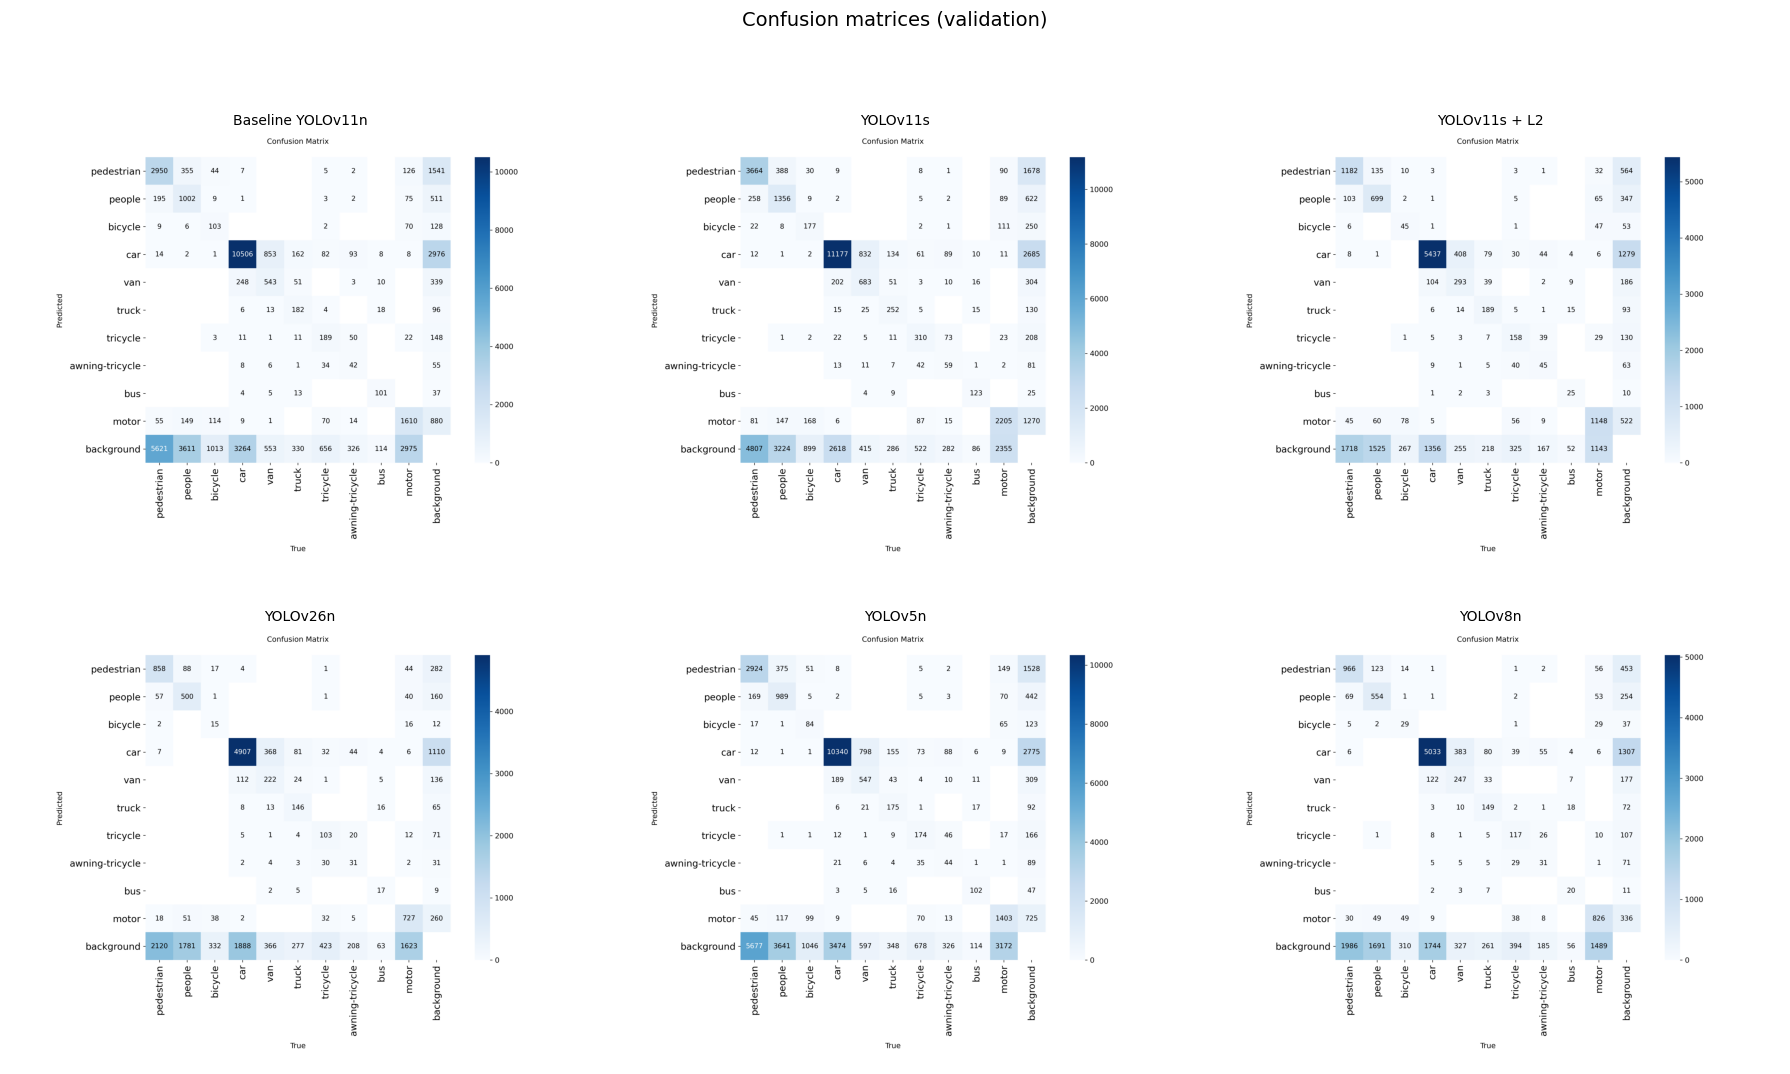

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, run in zip(axes, RUNS):
    img_path = ROOT / run["rel"] / "confusion_matrix.png"
    if not img_path.is_file():
        ax.set_title("missing confusion_matrix.png")
        ax.axis("off")
        continue
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(run["label"], fontsize=10)
    ax.axis("off")

plt.suptitle("Confusion matrices (validation)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


<a id="precision-recall-curves-all-six-models"></a>
## Precision-recall curves: all six models

The PR curves below show per-class detection behavior at varying confidence thresholds. Compare the same class across panels to see which model maintains higher precision at the same recall level. The mAP@50 value in the table is the single-number summary, but these curves reveal where each model struggles class by class.


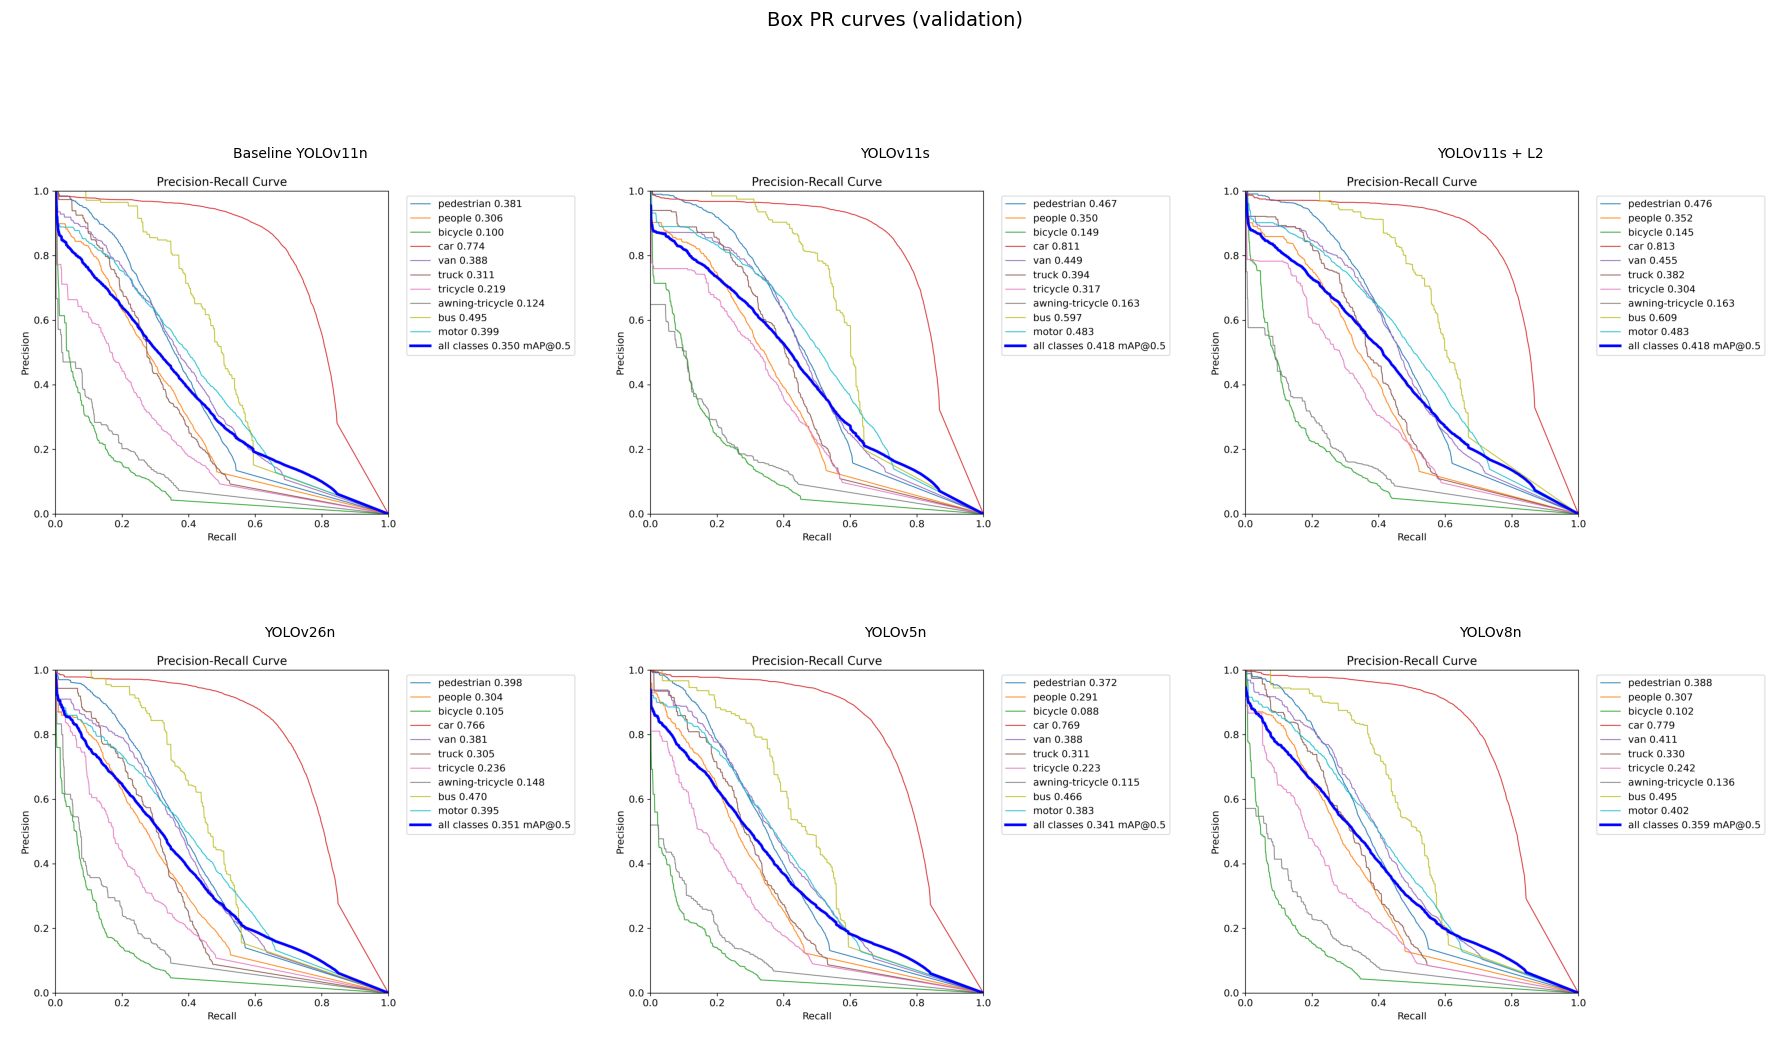

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, run in zip(axes, RUNS):
    img_path = ROOT / run["rel"] / "BoxPR_curve.png"
    if not img_path.is_file():
        ax.set_title("missing BoxPR_curve.png")
        ax.axis("off")
        continue
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(run["label"], fontsize=10)
    ax.axis("off")

plt.suptitle("Box PR curves (validation)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


<a id="overall-analysis-and-discussion"></a>
## Overall Analysis and Discussion

### Which Model Performed Best?

**YOLOv11s** achieved the highest mAP@50 (0.4135) and recall (0.4014) among all six models, making it the strongest detector in this comparison. **YOLOv11s + L2** came in a close second with nearly identical mAP (0.4122) but better generalization behavior, making it the most well-rounded model overall.

Among the comparison models, **YOLOv8n** performed best with a mAP@50 of 0.3595, outperforming both YOLOv26n (0.3491) and YOLOv5n (0.3401). This suggests that YOLOv8n is a stronger architecture than YOLOv5n on this dataset, and that YOLOv26n, while a newer model, may need more training epochs to fully converge.

### Effect of Model Size

Comparing YOLOv11n (2.59M params, mAP 0.3494) to YOLOv11s (9.43M params, mAP 0.4135) shows a clear improvement from scaling up model capacity. The larger model learned more complex features and detected more objects, especially people and cars. However, the increased capacity also led to more overfitting, which is why the L2 experiment was necessary.

### Effect of Architecture

Among models with similar parameter counts (YOLOv11n: 2.59M, YOLOv26n: 2.60M, YOLOv8n: 3.01M, YOLOv5n: 1.87M), YOLOv11n outperformed YOLOv26n and YOLOv5n, and was slightly behind YOLOv8n. This suggests that within the nano/small model tier, YOLOv11 and YOLOv8 are the stronger architectures for this dataset. YOLOv26n's lower performance is likely explained by incomplete convergence; it ran the full 200 epochs without early stopping, suggesting it was still improving when training ended.

### Generalization Behavior

Looking at the Val-train box column, models ranked from best to worst generalization are:
1. YOLOv26n (-0.006): essentially no gap, best generalization
2. YOLOv8n (0.021): very small gap
3. YOLOv11n (0.025): small gap
4. YOLOv11s + L2 (0.038): small gap after regularization
5. YOLOv5n (0.084): moderate gap
6. YOLOv11s (0.118): largest gap before regularization

This ranking shows that smaller models tend to generalize better on this dataset, and that the L2 regularization meaningfully improved YOLOv11s's generalization without hurting performance.

### Common Challenges Across All Models

Regardless of architecture, all six models share the same weaknesses: strong performance on car and motor, decent performance on pedestrian and people, and weak performance on bicycle, tricycle, and awning-tricycle. This pattern is consistent across every confusion matrix and PR curve, which strongly suggests the bottleneck is **dataset imbalance** rather than model architecture. No architecture change alone was enough to overcome the underrepresentation of these classes in the training data.


<a id="notes-on-the-comparison"></a>
## Notes on the Comparison

- Models that triggered early stopping (YOLOv11n at epoch 179, YOLOv11s at epoch 147, YOLOv11s+L2 at epoch 168) had converged before the 200-epoch limit. Models that ran the full 200 epochs (YOLOv26n, YOLOv5n, YOLOv8n) may have continued improving with more training time.
- All metrics are evaluated on the VisDrone2019 validation set. Test set evaluation using the challenge split is done separately.
- Parameter counts are approximate guide values from Ultralytics documentation.
